In [116]:
from pathlib import Path

import duckdb

import osmnx as ox
import pandas as pd


import mmlib

from mmlib import mmplot as mplt

# Veículos interessantes
- 0: Resultado do map matching é quase perfeito
- 1: Resultado do map matching é muito bom
- 10: Resultado do map matching sofre de desvio desnecessário
- 33: Resultado do map matching sofre de desvio desnecessário extremo
- 30: Quase perfeito

In [117]:
ROOT_PATH = Path(".").resolve().absolute()
GRAPHHOPPER_BASE_URL = "http://localhost:8989"
GRAPHHOPPER_GPS_ACCURACY = 50  # meters
VEHICLE_ID = 33
SAMPLE_RATE: int | None = 2  # seconds

In [118]:
GROUND_TRUTH_PATH = ROOT_PATH / "sumo/simulations/ohare-chicago/output/fcd.parquet"
NOISE_PARQUET = ROOT_PATH / "sumo/simulations/ohare-chicago/output/fcd_noisy.parquet"
NETWORK_PATH = ROOT_PATH / "networks/filtered/ohare-filtered.osm.xml"

In [119]:
type Coordinate = tuple[float, float]  # (latitude, longitude)

In [120]:
duckdb.query(f"SELECT COUNT(DISTINCT vehicle_id) FROM '{GROUND_TRUTH_PATH}'")

┌────────────────────────────┐
│ count(DISTINCT vehicle_id) │
│           int64            │
├────────────────────────────┤
│                       1755 │
└────────────────────────────┘

In [121]:
def load_road_dataset(path: Path) -> pd.DataFrame:
    df = duckdb.query(
        f"""                
        SELECT lon, lat, TO_TIMESTAMP(time) AS timestamp, edge_id, raw_edge_id
        FROM '{path}'
        WHERE vehicle_id = {VEHICLE_ID}
        ORDER BY time ASC
        """
    ).to_df()

    if SAMPLE_RATE is not None:
        df = df.resample(f"{SAMPLE_RATE:.2f}s", on="timestamp").first().reset_index()

    return df

In [144]:
gt_df = load_road_dataset(GROUND_TRUTH_PATH)
gt_df

,timestamp,lon,lat,edge_id,raw_edge_id
0,1969-12-31 21:01:36-03:00,-87.901117,41.977244,981212641,981212641
1,1969-12-31 21:01:38-03:00,-87.901087,41.977260,981212641,981212641
2,1969-12-31 21:01:40-03:00,-87.900974,41.977318,981212641,981212641
3,1969-12-31 21:01:42-03:00,-87.900781,41.977418,981212641,981212641
4,1969-12-31 21:01:44-03:00,-87.900502,41.977554,12793948428,:12793948428_0
...,...,...,...,...,...
78,1969-12-31 21:04:12-03:00,-87.879020,41.976362,72677302,72677302
79,1969-12-31 21:04:14-03:00,-87.878841,41.975916,72677302,72677302
80,1969-12-31 21:04:16-03:00,-87.878678,41.975474,72677302,72677302
81,1969-12-31 21:04:18-03:00,-87.878539,41.975021,72677302,72677302


In [123]:
noisy_df = load_road_dataset(NOISE_PARQUET)
noisy_df

,timestamp,lon,lat,edge_id,raw_edge_id
0,1969-12-31 21:01:36-03:00,-87.901097,41.977213,981212641,981212641
1,1969-12-31 21:01:38-03:00,-87.901049,41.977240,981212641,981212641
2,1969-12-31 21:01:40-03:00,-87.901093,41.977291,981212641,981212641
3,1969-12-31 21:01:42-03:00,-87.900797,41.977418,981212641,981212641
4,1969-12-31 21:01:44-03:00,-87.900512,41.977575,12793948428,:12793948428_0
...,...,...,...,...,...
78,1969-12-31 21:04:12-03:00,-87.879004,41.976358,72677302,72677302
79,1969-12-31 21:04:14-03:00,-87.878791,41.975965,72677302,72677302
80,1969-12-31 21:04:16-03:00,-87.878556,41.975491,72677302,72677302
81,1969-12-31 21:04:18-03:00,-87.878675,41.974991,72677302,72677302


In [124]:
gt_gps_coordinates = gt_df[["lat", "lon", "timestamp"]].to_records(index=False).tolist()
gt_points = gt_df[["lat", "lon"]].to_records(index=False).tolist()
gt_edge_ids = gt_df["edge_id"].tolist()

print("GROUND TRUTH: ", len(gt_points), "points")
print("first 3 points:", gt_points[:3])
print("first 3 edge ids:", gt_edge_ids[:3])
print("fist 3 coordinates:", gt_gps_coordinates[:3])

GROUND TRUTH:  83 points
first 3 points: [(41.97724429613347, -87.90111722325061), (41.97725985964414, -87.90108711895539), (41.97731813503751, -87.90097439735906)]
first 3 edge ids: ['981212641', '981212641', '981212641']
fist 3 coordinates: [(41.97724429613347, -87.90111722325061, Timestamp('1969-12-31 21:01:36-0300', tz='America/Fortaleza')), (41.97725985964414, -87.90108711895539, Timestamp('1969-12-31 21:01:38-0300', tz='America/Fortaleza')), (41.97731813503751, -87.90097439735906, Timestamp('1969-12-31 21:01:40-0300', tz='America/Fortaleza'))]


In [125]:
noisy_gps_coordinates = (
    noisy_df[["lat", "lon", "timestamp"]].to_records(index=False).tolist()
)
noisy_points = noisy_df[["lat", "lon"]].to_records(index=False).tolist()
noisy_edge_ids = noisy_df["edge_id"].tolist()

print("NOISY: ", len(noisy_points), "points")
print("first 3 points:", noisy_points[:3])
print("first 3 edge ids:", noisy_edge_ids[:3])
print("first 3 coordinates:", noisy_gps_coordinates[:3])

NOISY:  83 points
first 3 points: [(41.97721343507333, -87.90109722200769), (41.97724003597713, -87.90104893927439), (41.97729050213191, -87.90109346579854)]
first 3 edge ids: ['981212641', '981212641', '981212641']
first 3 coordinates: [(41.97721343507333, -87.90109722200769, Timestamp('1969-12-31 21:01:36-0300', tz='America/Fortaleza')), (41.97724003597713, -87.90104893927439, Timestamp('1969-12-31 21:01:38-0300', tz='America/Fortaleza')), (41.97729050213191, -87.90109346579854, Timestamp('1969-12-31 21:01:40-0300', tz='America/Fortaleza'))]


In [126]:

matcher = mmlib.graphhopper_matcher(
    GRAPHHOPPER_BASE_URL, gps_accuracy=GRAPHHOPPER_GPS_ACCURACY
)
match_result = matcher.map_match(noisy_gps_coordinates)
match_result.plot()

In [127]:
ground_truth_edges = set(gt_edge_ids)
matched_edges = set(match_result.edge_ids)
(
    len(matched_edges),
    len(ground_truth_edges),
    len(matched_edges & ground_truth_edges),
    len(matched_edges.symmetric_difference(ground_truth_edges)),
)

(42, 24, 13, 40)

In [128]:
G = ox.graph_from_xml(ROOT_PATH / "networks/filtered/ohare-filtered.osm.xml", simplify=False, retain_all=False)

In [129]:
mplt.plot_map_matching_from_osmid(
    graph=G,
    ground_truth_osmid_path=gt_edge_ids,
    map_matched_osmid_path=match_result.edge_ids,
)

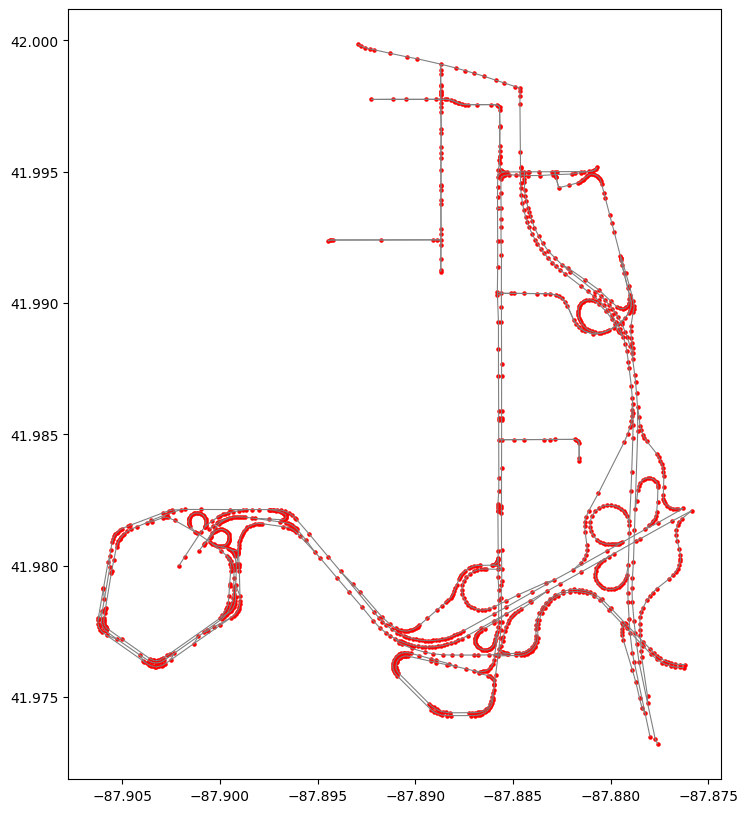

In [130]:
nodes, edges = ox.graph_to_gdfs(G)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(ax=ax, linewidth=0.8, color="gray")
nodes.plot(ax=ax, markersize=5, color="red")

plt.show()

In [ ]:
import folium
import networkx as nx

type edge_id = str


def plot_map_matching_from_osmid_folium(
    graph: nx.MultiDiGraph,
    ground_truth_osmid_path: list[edge_id],
    map_matched_osmid_path: list[edge_id],
):
    """
    Folium version of map-matching visualization.
    Shows:
      - street network (gray)
      - ground truth path (green)
      - map matched path (blue)
    Includes tooltips, layer toggles and summary stats.
    """

    nodes, edges = ox.graph_to_gdfs(graph)
    edges_wgs = edges.to_crs(epsg=4326)

    center = edges_wgs.union_all().centroid
    m = folium.Map(
        location=[center.y, center.x], zoom_start=15, control_scale=True, tiles=None
    )
    folium.TileLayer(
        "OpenStreetMap",
        name="OpenStreetMap Light (30% Opacity)",
        opacity=0.3,
        show=False,
    ).add_to(m)

    folium.TileLayer(
        tiles="CartoDB dark_matter",
        name="CartoDB Dark Matter",
        attr='&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
        show=True,
    ).add_to(m)

    folium.TileLayer(
        "CartoDB positron",
        name="CartoDB Positron",
        opacity=0.60,
        attr="&copy; <a href='https://carto.com/attributions'>CARTO</a>",
        show=False,
    ).add_to(m)

    folium.GeoJson(
        edges_wgs,
        name="Street Network",
        style_function=lambda x: {"color": "lightblue", "weight": 2, "opacity": 0.8},
        tooltip=folium.GeoJsonTooltip(fields=["osmid"], aliases=["OSMID"]),
    ).add_to(m)

    def edges_by_osmid(osmid_list):
        """Return subset of edges GeoDataFrame filtered by OSMIDs."""
        osmids_str = {str(osm) for osm in osmid_list}
        mask = edges_wgs["osmid"].astype(str).isin(osmids_str)
        return edges_wgs[mask]

    if map_matched_osmid_path:
        mm_edges = edges_by_osmid(map_matched_osmid_path)
        folium.GeoJson(
            mm_edges,
            name="Map Matched",
            style_function=lambda x: {"color": "blue", "weight": 4, "opacity": 0.6},
            tooltip=folium.GeoJsonTooltip(fields=["osmid"], aliases=["OSMID"]),
        ).add_to(m)

    if ground_truth_osmid_path:
        gt_edges = edges_by_osmid(ground_truth_osmid_path)
        folium.GeoJson(
            gt_edges,
            name="Ground Truth",
            style_function=lambda x: {"color": "green", "weight": 4, "opacity": 0.6},
            tooltip=folium.GeoJsonTooltip(fields=["osmid"], aliases=["OSMID"]),
        ).add_to(m)

    # --- Optional: nodes layer (toggleable) ---
    nodes_wgs = nodes.to_crs(epsg=4326)
    nodes_wgs["osmid"] = nodes_wgs.index.copy().astype(str)
    folium.GeoJson(
        nodes_wgs,
        name="Nodes",
        marker=folium.Circle(radius=2, color="gray", fill=True, fill_opacity=0.5),
        tooltip=folium.GeoJsonTooltip(fields=["osmid"], aliases=["Node ID"]),
    ).add_to(m)

    # --- Compute stats ---
    gt_edges = set(ground_truth_osmid_path)
    mm_edges = set(map_matched_osmid_path)
    matched = gt_edges & mm_edges
    added = mm_edges - gt_edges
    missing = gt_edges - mm_edges
    difference = gt_edges ^ mm_edges

    # --- Add statistics box ---
    # --- Add statistics table ---
    # Compute statistics for display
    stats = {
        "Matched": len(matched),
        "Added": len(added),
        "Missing": len(missing),
        "Difference": len(difference),
        "Ground Truth Edges": len(ground_truth_osmid_path),
        "Map Matched Edges": len(map_matched_osmid_path),
    }

    # Build stats HTML table dynamically with horizontal lines between rows
    stats_rows = "".join(
        f"""
        <tr>
            <td>{key}</td>
            <td style="text-align:right;">{value}</td>
        </tr>
        <tr><td colspan="2"><hr style="margin:2px 0; border:none; border-top:1px solid #222;"></td></tr>
        """
        for key, value in stats.items()
    )

    stats_html = f"""
    <div style="background-color:white; padding:10px; border-radius:8px;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.2); font-size:13px;
                position: absolute; left: 10px; bottom: 10px; z-index: 9999;">
        <b>Map Matching Summary</b>
        <table style="margin-top:5px; border-collapse:collapse;">
            <tr>
                <th style="text-align:left; padding-right:10px;">Metric</th>
                <th style="text-align:right;">Count</th>
            </tr>
            {stats_rows}
        </table>
    </div>
    """
    folium.Marker(
        [center.y, center.x],
        icon=folium.DivIcon(html=stats_html),
    ).add_to(m)

    # --- Layer control ---
    folium.LayerControl(collapsed=False).add_to(m)

    return m

In [132]:
nodes, edges = ox.graph_to_gdfs(G)
nodes_wgs = nodes.to_crs(epsg=4326)
nodes.index

Index([1153867776, 1153867781,   29786118, 1153867783, 1153867787, 1153867790,
       1153867794, 1153867797,   29786137,   29786138,
       ...
       1153867749, 1153867750, 1153867751, 1153867758, 1153867761, 1153867763,
       1153867765, 1153867766,   29786106, 1153867774],
      dtype='int64', name='osmid', length=1330)

In [133]:
plot_map_matching_from_osmid_folium(
    graph=G,
    ground_truth_osmid_path=gt_edge_ids,
    map_matched_osmid_path=match_result.edge_ids,
)